**Proje Konusu: YSA’ların sınırları**

25*25’lik binary bir matris girişine karşılık aşağıdaki çıktıları üreten 5 YSA eğitiniz.

- A) Matriste 5 nokta (rasgele konumlarda) bulunmaktadır. Model bu noktalardan birbirine en yakın olan ikisi arasındaki Manhattan mesafesini çıktı olarak verecektir. 
- B) A’nin aynısı sadece en yakın yerine en uzak olan ikisi… 
- C) Matriste değişken sayıda (her girişte farklı sayıda olabilir) N adet (1 10 arası) nokta (rasgele konumlarda) bulunmaktadır. Model nokta sayısını çıktı olarak verecektir. 
- D) C’nin aynısı ama çıkış, nokta sayısının tek mi çift mi olduğu 
- E) C’nin aynısı ama çıkış, nokta sayısı tek ise sol üst köşeye en yakın olan noktanın sol üst köşeye Manhattan mesafesi, çift ise sağ alt köşeye en yakın olan noktanın sağ alt köşeye Manhattan mesafesi

YSA modeli olarak RNN, MLP, CNN, Transformer vb. istediğinizi kullanabilirsiniz.<br> 
Her problemde farklı birini de aynılarını da kullanabilirsiniz.

- 5 problemin her biri için: En az 800 örneğe sahip eğitim, 200 örneğe sahip test kümesi oluşturunuz.
- Her eğitim ve test kümesinde çıkışların dağılımı eşit olmalıdır. Örneğin A’da aradaki mesafeler 1-50 aralığında değişiyorsa her aralıktan eşit sayıda örnek olmalıdır. Kümeler buna göre oluşturulmalıdır.
- YSA ların hiperparametre optimizasyonunu nasıl yaptığınızı raporlayınız.
- Eğitim kümesinin çeyrek, yarım ve tam halleri için eğitim yapıp test kümesi üzerindeki performansını raporlayınız.
- Yanlış ve doğru yapılan test örneklerini kendi gözünüzle inceleyip, modellerin neyi öğrenebildiğini / öğrenemediğini yorumlayınız.
- Bulgularınızı tablolar ve grafiklerle sunun, yorumlayın.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import math
from collections import Counter
from util import load_dataset, plot_mat

In [2]:
GRID_SIZE = 25
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

x_train, y_train, x_test, y_test = load_dataset('E')

[+] Problem E veri seti başarıyla yüklendi.
    Train -> X: (1200, 25, 25), y: (1200,)
    Test  -> X: (400, 25, 25), y: (400,)


In [3]:
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super(SelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.embed_dim)
        attn_weights = F.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, V)
        
        return out

class ProblemECNN(nn.Module):
    def __init__(self, embedDim=16, hiddenDim=64):
        super().__init__()
        self.pixelEmbedding = nn.Linear(3, embedDim)
        
        self.attention = SelfAttention(embedDim)
        
        self.mlp = nn.Sequential(
            nn.Linear(embedDim * 2, hiddenDim),
            Sine(),
            nn.Linear(hiddenDim, hiddenDim),
            Sine(),
            nn.Linear(hiddenDim, 1)
        )

        yCoords, xCoords = torch.meshgrid(torch.arange(25), torch.arange(25), indexing='ij')
        coords = torch.stack([xCoords.flatten(), yCoords.flatten()], dim=-1).float()
        self.register_buffer('coordsGrid', coords)

    def forward(self, x):
        batchSize = x.size(0)
        xMask = x.view(batchSize, 625, 1)
        batchCoords = self.coordsGrid.unsqueeze(0).expand(batchSize, -1, -1)
        
        xWithCoords = torch.cat([xMask, batchCoords], dim=-1)
        emb = self.pixelEmbedding(xWithCoords)
        emb = emb * xMask
        
        attnOut = self.attention(emb)
        
        # 1. SUM POOLING (Teklik/Çiftlik sayımı için)
        pooledSum = torch.sum(attnOut * xMask, dim=1)
        
        # 2. MAX POOLING (Koordinat kimliklerini korumak için)
        # Siyah piksellerin (0'ların) Max Pooling'i bozmaması için onları eksi sonsuz yapıyoruz
        attnOutMasked = attnOut.masked_fill(xMask == 0, float('-inf'))
        pooledMax = torch.max(attnOutMasked, dim=1)[0]
        
        # İki bilgiyi birleştir
        pooled = torch.cat([pooledSum, pooledMax], dim=-1)
        
        out = self.mlp(pooled)
        if self.training:
            return out
        else:
            return torch.round(out)

In [4]:
torch.manual_seed(11337)

x_train_tensor = torch.tensor(x_train).float()
y_train_tensor = torch.tensor(y_train).float()
x_test_tensor = torch.tensor(x_test).float()
y_test_tensor = torch.tensor(y_test).float()

# 2. Artık Tensör oldukları için TensorDataset sorunsuz çalışacaktır
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=True)

# 2. Model, Loss ve Optimizatör
model = ProblemECNN().to(device)
model.train()

criterion = nn.MSELoss() 
optimizer = optim.AdamW(model.parameters())

epochs = 10000

In [5]:
for epoch in range(epochs):
    model.train()
    train_correct = 0
    total_samples = 0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.float().squeeze().to(device)

        optimizer.zero_grad()
        predictions = model(batch_x).squeeze()

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            predicted_labels = torch.round(predictions)
            train_correct += (predicted_labels == batch_y).sum().item()
            total_samples += batch_y.size(0)

    train_accuracy = train_correct / total_samples

    model.eval()
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.float().squeeze().to(device)
            
            predictions = model(batch_x).squeeze()
            predicted_labels = torch.round(predictions)
            
            test_correct += (predicted_labels == batch_y).sum().item()
            test_total += batch_y.size(0)            
            
    test_accuracy = test_correct / test_total
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: %{train_accuracy*100:.2f} | Test Acc: %{test_accuracy*100:.2f}")

Epoch [100/10000] | Train Acc: %3.92 | Test Acc: %3.00
Epoch [200/10000] | Train Acc: %6.75 | Test Acc: %7.75
Epoch [300/10000] | Train Acc: %8.33 | Test Acc: %7.25
Epoch [400/10000] | Train Acc: %9.75 | Test Acc: %12.00
Epoch [500/10000] | Train Acc: %9.67 | Test Acc: %9.50
Epoch [600/10000] | Train Acc: %11.58 | Test Acc: %10.25
Epoch [700/10000] | Train Acc: %13.92 | Test Acc: %9.50
Epoch [800/10000] | Train Acc: %14.42 | Test Acc: %11.00
Epoch [900/10000] | Train Acc: %15.42 | Test Acc: %15.75
Epoch [1000/10000] | Train Acc: %25.00 | Test Acc: %21.75
Epoch [1100/10000] | Train Acc: %37.50 | Test Acc: %33.50
Epoch [1200/10000] | Train Acc: %44.75 | Test Acc: %36.25
Epoch [1300/10000] | Train Acc: %48.75 | Test Acc: %39.00
Epoch [1400/10000] | Train Acc: %51.75 | Test Acc: %44.00
Epoch [1500/10000] | Train Acc: %53.17 | Test Acc: %37.25
Epoch [1600/10000] | Train Acc: %54.92 | Test Acc: %43.00
Epoch [1700/10000] | Train Acc: %14.42 | Test Acc: %13.75
Epoch [1800/10000] | Train Acc: %

In [6]:
# ÇIKTI (DROPOUT YOK):
"""
Epoch [100/10000] | Train Acc: %2.50 | Test Acc: %2.50
Epoch [200/10000] | Train Acc: %4.17 | Test Acc: %5.75
Epoch [300/10000] | Train Acc: %6.83 | Test Acc: %5.00
Epoch [400/10000] | Train Acc: %8.67 | Test Acc: %12.00
Epoch [500/10000] | Train Acc: %9.25 | Test Acc: %10.50
Epoch [600/10000] | Train Acc: %11.67 | Test Acc: %14.00
Epoch [700/10000] | Train Acc: %10.67 | Test Acc: %11.75
Epoch [800/10000] | Train Acc: %12.75 | Test Acc: %10.00
Epoch [900/10000] | Train Acc: %12.33 | Test Acc: %13.75
Epoch [1000/10000] | Train Acc: %14.67 | Test Acc: %12.00
Epoch [1100/10000] | Train Acc: %12.50 | Test Acc: %14.50
Epoch [1200/10000] | Train Acc: %13.50 | Test Acc: %15.00
Epoch [1300/10000] | Train Acc: %11.33 | Test Acc: %13.00
Epoch [1400/10000] | Train Acc: %17.00 | Test Acc: %11.50
Epoch [1500/10000] | Train Acc: %16.92 | Test Acc: %14.25
Epoch [1600/10000] | Train Acc: %18.58 | Test Acc: %15.25
Epoch [1700/10000] | Train Acc: %19.17 | Test Acc: %15.00
Epoch [1800/10000] | Train Acc: %15.08 | Test Acc: %15.75
Epoch [1900/10000] | Train Acc: %16.17 | Test Acc: %14.75
Epoch [2000/10000] | Train Acc: %18.33 | Test Acc: %16.00
Epoch [2100/10000] | Train Acc: %19.33 | Test Acc: %15.00
Epoch [2200/10000] | Train Acc: %19.92 | Test Acc: %15.00
Epoch [2300/10000] | Train Acc: %21.58 | Test Acc: %14.25
Epoch [2400/10000] | Train Acc: %23.25 | Test Acc: %14.00
Epoch [2500/10000] | Train Acc: %21.33 | Test Acc: %13.50
Epoch [2600/10000] | Train Acc: %21.83 | Test Acc: %15.25
Epoch [2700/10000] | Train Acc: %20.75 | Test Acc: %13.50
Epoch [2800/10000] | Train Acc: %21.92 | Test Acc: %13.25
Epoch [2900/10000] | Train Acc: %26.33 | Test Acc: %13.00
Epoch [3000/10000] | Train Acc: %32.42 | Test Acc: %13.25
Epoch [3100/10000] | Train Acc: %35.50 | Test Acc: %14.75
Epoch [3200/10000] | Train Acc: %42.08 | Test Acc: %15.00
Epoch [3300/10000] | Train Acc: %42.50 | Test Acc: %16.00
Epoch [3400/10000] | Train Acc: %40.33 | Test Acc: %18.00
Epoch [3500/10000] | Train Acc: %46.58 | Test Acc: %16.50
Epoch [3600/10000] | Train Acc: %53.50 | Test Acc: %14.75
Epoch [3700/10000] | Train Acc: %55.00 | Test Acc: %17.00
Epoch [3800/10000] | Train Acc: %56.92 | Test Acc: %17.25
Epoch [3900/10000] | Train Acc: %40.17 | Test Acc: %17.00
Epoch [4000/10000] | Train Acc: %40.75 | Test Acc: %16.00
Epoch [4100/10000] | Train Acc: %61.25 | Test Acc: %19.00
Epoch [4200/10000] | Train Acc: %54.08 | Test Acc: %18.50
Epoch [4300/10000] | Train Acc: %62.17 | Test Acc: %21.50
Epoch [4400/10000] | Train Acc: %23.83 | Test Acc: %15.75
Epoch [4500/10000] | Train Acc: %61.83 | Test Acc: %20.75
Epoch [4600/10000] | Train Acc: %62.08 | Test Acc: %21.25
Epoch [4700/10000] | Train Acc: %53.83 | Test Acc: %21.25
Epoch [4800/10000] | Train Acc: %59.92 | Test Acc: %19.25
Epoch [4900/10000] | Train Acc: %31.42 | Test Acc: %13.75
Epoch [5000/10000] | Train Acc: %66.83 | Test Acc: %23.00
Epoch [5100/10000] | Train Acc: %67.08 | Test Acc: %21.00
Epoch [5200/10000] | Train Acc: %62.42 | Test Acc: %19.75
Epoch [5300/10000] | Train Acc: %59.58 | Test Acc: %20.25
Epoch [5400/10000] | Train Acc: %66.92 | Test Acc: %20.25
Epoch [5500/10000] | Train Acc: %58.25 | Test Acc: %22.25
Epoch [5600/10000] | Train Acc: %23.92 | Test Acc: %18.00
Epoch [5700/10000] | Train Acc: %61.83 | Test Acc: %20.50
Epoch [5800/10000] | Train Acc: %33.17 | Test Acc: %20.75
Epoch [5900/10000] | Train Acc: %72.58 | Test Acc: %23.00
Epoch [6000/10000] | Train Acc: %72.83 | Test Acc: %23.75
Epoch [6100/10000] | Train Acc: %70.33 | Test Acc: %24.50
Epoch [6200/10000] | Train Acc: %54.92 | Test Acc: %23.50
Epoch [6300/10000] | Train Acc: %67.08 | Test Acc: %24.25
Epoch [6400/10000] | Train Acc: %73.25 | Test Acc: %21.75
Epoch [6500/10000] | Train Acc: %61.83 | Test Acc: %22.50
Epoch [6600/10000] | Train Acc: %69.67 | Test Acc: %22.25
Epoch [6700/10000] | Train Acc: %56.83 | Test Acc: %19.25
Epoch [6800/10000] | Train Acc: %75.83 | Test Acc: %23.75
Epoch [6900/10000] | Train Acc: %75.25 | Test Acc: %25.25
Epoch [7000/10000] | Train Acc: %61.67 | Test Acc: %25.00
Epoch [7100/10000] | Train Acc: %76.25 | Test Acc: %23.25
Epoch [7200/10000] | Train Acc: %73.42 | Test Acc: %24.50
Epoch [7300/10000] | Train Acc: %74.83 | Test Acc: %25.50
Epoch [7400/10000] | Train Acc: %48.17 | Test Acc: %21.00
Epoch [7500/10000] | Train Acc: %75.00 | Test Acc: %25.25
Epoch [7600/10000] | Train Acc: %65.25 | Test Acc: %25.00
Epoch [7700/10000] | Train Acc: %75.42 | Test Acc: %25.00
Epoch [7800/10000] | Train Acc: %72.58 | Test Acc: %25.75
Epoch [7900/10000] | Train Acc: %78.25 | Test Acc: %25.75
Epoch [8000/10000] | Train Acc: %77.25 | Test Acc: %26.25
Epoch [8100/10000] | Train Acc: %68.33 | Test Acc: %26.25
Epoch [8200/10000] | Train Acc: %50.83 | Test Acc: %22.50
Epoch [8300/10000] | Train Acc: %61.75 | Test Acc: %24.00
Epoch [8400/10000] | Train Acc: %77.67 | Test Acc: %28.25
Epoch [8500/10000] | Train Acc: %50.67 | Test Acc: %23.25
Epoch [8600/10000] | Train Acc: %74.25 | Test Acc: %27.50
Epoch [8700/10000] | Train Acc: %74.33 | Test Acc: %28.25
Epoch [8800/10000] | Train Acc: %58.00 | Test Acc: %24.75
Epoch [8900/10000] | Train Acc: %70.92 | Test Acc: %26.75
Epoch [9000/10000] | Train Acc: %74.00 | Test Acc: %26.75
Epoch [9100/10000] | Train Acc: %24.08 | Test Acc: %14.25
Epoch [9200/10000] | Train Acc: %70.83 | Test Acc: %25.25
Epoch [9300/10000] | Train Acc: %75.92 | Test Acc: %27.00
Epoch [9400/10000] | Train Acc: %77.17 | Test Acc: %25.75
Epoch [9500/10000] | Train Acc: %77.58 | Test Acc: %27.25
Epoch [9600/10000] | Train Acc: %78.25 | Test Acc: %27.25
Epoch [9700/10000] | Train Acc: %70.58 | Test Acc: %26.25
Epoch [9800/10000] | Train Acc: %77.25 | Test Acc: %29.75
Epoch [9900/10000] | Train Acc: %77.67 | Test Acc: %29.00
Epoch [10000/10000] | Train Acc: %66.92 | Test Acc: %25.25
""";

In [7]:
def predict(model, x_data):
    model.eval()
    
    if not isinstance(x_data, torch.Tensor):
        x_data = torch.tensor(x_data, dtype=torch.float32)

    is_single = (x_data.dim() == 2)
    
    if is_single:
        x_data = x_data.unsqueeze(0)
        
    device = next(model.parameters()).device
    x_data = x_data.to(device)

    with torch.no_grad():
        sonuc = model(x_data)
        
    sonuc_tensor = torch.round(sonuc).int()
    
    if is_single:
        return sonuc_tensor.item()
    else:
        return sonuc_tensor.flatten()


Hata Farkı Haritası (Fark: Adet): {1: 165, 4: 5, 6: 1, 2: 47, 3: 14, 8: 1, 25: 1, 5: 2, 9: 1, 7: 1}


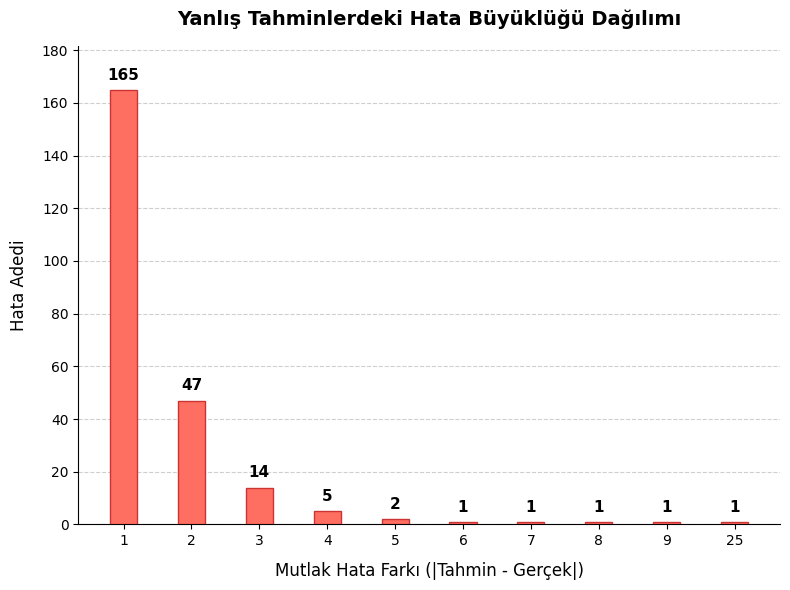

In [8]:
wrong_indices = []
error_diffs = []

with torch.no_grad():
    if not isinstance(x_test, torch.Tensor):
        x_test = torch.tensor(x_test, dtype=torch.float32)
    x_test = x_test.to(device)
    preds = predict(model, x_test)

for i, (pred, y) in enumerate(zip(preds, y_test, strict=True)):
    if pred != y:
        # Hatanın büyüklüğünü (mutlak farkını) hesapla
        diff = abs(int(pred) - int(y)) 
        
        wrong_indices.append((i, y, pred))
        error_diffs.append(diff)

Y_EKSENI_MAKSIMUM = 100 

diff_map = dict(Counter(error_diffs))
print("\nHata Farkı Haritası (Fark: Adet):", diff_map)

if error_diffs:
    sorted_diffs = sorted(diff_map.keys())
    counts = [diff_map[d] for d in sorted_diffs]
    x_labels = [str(d) for d in sorted_diffs]

    fig_width = max(8, len(sorted_diffs) * 0.7)
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    
    bars = ax.bar(x_labels, counts, color='#FF6F61', edgecolor='#CC3333', width=0.4, zorder=3)

    if len(sorted_diffs) < 6:
        ax.set_xlim(-0.5, 5.5)

    max_count = max(counts) if counts else 1
    
    # Her zaman 0'dan başlar. Tavan değeri ise belirlediğiniz limit (100) ile grafikteki en yüksek bar arasında seçilir.
    ax.set_ylim(0, max(Y_EKSENI_MAKSIMUM, max_count + (max_count * 0.1)))

    for bar in bars:
        yval = bar.get_height()
        if yval > 0: 
            # Yazıları yazdırırken üst kısımdaki boşluk (tavan yüksekliğine göre ayarlandı)
            ax.text(bar.get_x() + bar.get_width()/2, yval + (ax.get_ylim()[1] * 0.015), 
                    int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title('Yanlış Tahminlerdeki Hata Büyüklüğü Dağılımı', fontsize=14, pad=15, fontweight='bold')
    ax.set_xlabel('Mutlak Hata Farkı (|Tahmin - Gerçek|)', fontsize=12, labelpad=10)
    ax.set_ylabel('Hata Adedi', fontsize=12, labelpad=10)
    
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


--- İlk 5 Hatalı Tahmin Görselleştiriliyor ---

İndeks: 1 | Gerçek Değer: 25 | Tahmin: 26 | Hata Payı: 1


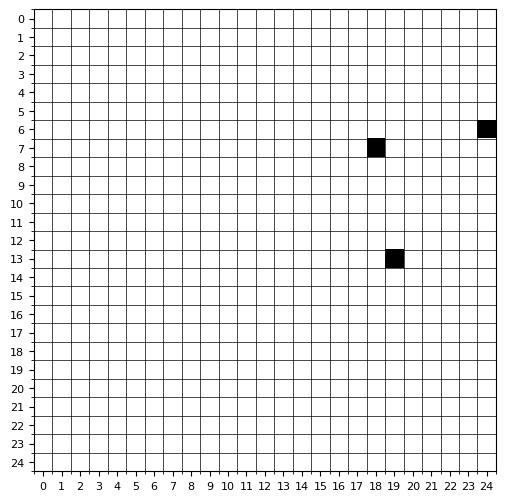


İndeks: 2 | Gerçek Değer: 10 | Tahmin: 6 | Hata Payı: 4


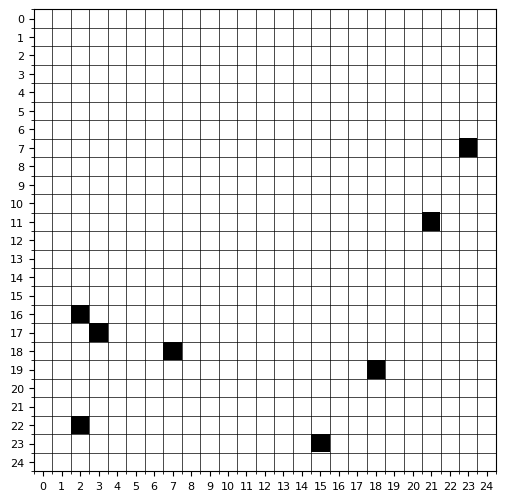


İndeks: 6 | Gerçek Değer: 4 | Tahmin: 3 | Hata Payı: 1


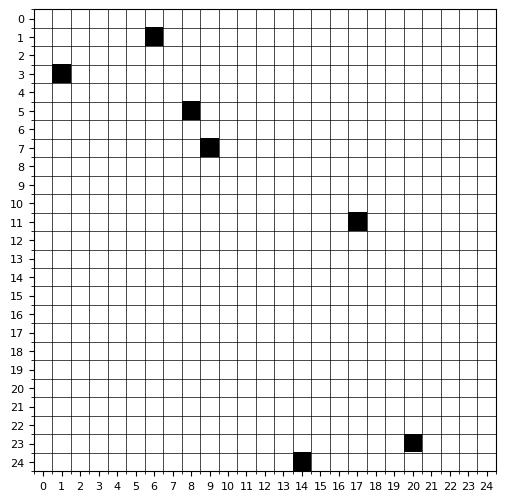


İndeks: 7 | Gerçek Değer: 0 | Tahmin: 4 | Hata Payı: 4


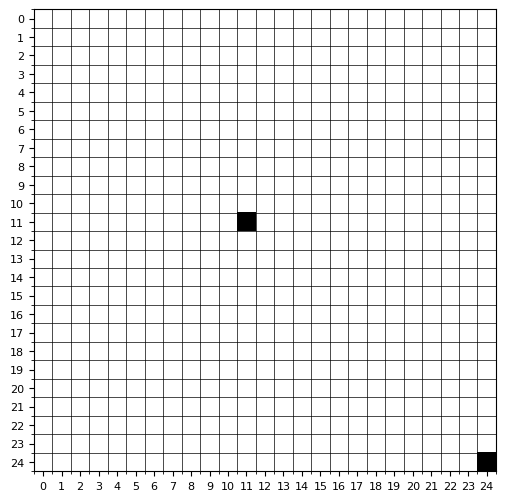


İndeks: 8 | Gerçek Değer: 15 | Tahmin: 14 | Hata Payı: 1


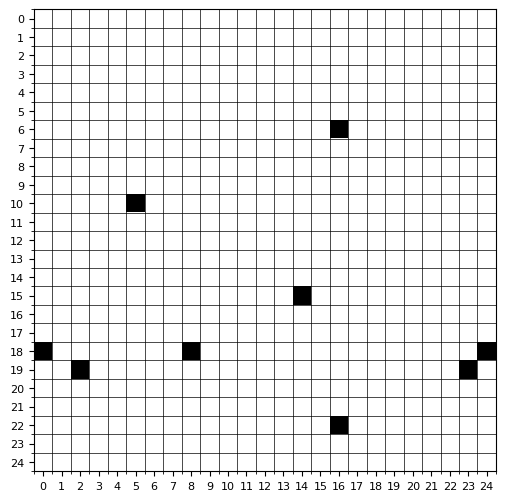

In [9]:
# Gösterilecek maksimum hatalı örnek sayısı
gosterilecek_adet = 5

print(f"\n--- İlk {gosterilecek_adet} Hatalı Tahmin Görselleştiriliyor ---")

for count, (idx, true_y, pred_y) in enumerate(wrong_indices):
    if count >= gosterilecek_adet:
        break # Sınıra ulaşınca döngüyü bitir
        
    fark = abs(int(pred_y) - int(true_y))
    print(f"\nİndeks: {idx} | Gerçek Değer: {true_y} | Tahmin: {pred_y} | Hata Payı: {fark}")
    
    # x_test GPU'da (cuda) olduğu için matplotlib sorun çıkarabilir.
    # plot_mat fonksiyonunuzun beklentisine göre x_test'i CPU'ya alıp numpy'a çeviriyoruz.
    # Eğer plot_mat doğrudan PyTorch tensörlerini destekliyorsa sadece x_test[idx] de yazabilirsiniz.
    matris = x_test[idx].cpu().numpy() if isinstance(x_test[idx], torch.Tensor) else x_test[idx]
    
    plot_mat(matris)